In [11]:
from trectools import TrecQrel
from  nltk.metrics import agreement
import pandas as pd

def qrel_eval(qrels_a, qrels_b, dataset, measure):
    a = TrecQrel(f'../data/msmarco-passage-{dataset}/qrels/{qrels_a}.qrels.txt')
    b = TrecQrel(f'../data/msmarco-passage-{dataset}/qrels/{qrels_b}.qrels.txt')

    # trectools uses q0 for the join, but this field is not uniformly set
    a.qrels_data['q0'] = '0'
    b.qrels_data['q0'] = '0'

    data = []
    for _, i in a.qrels_data.iterrows():
        data.append(("a", f'{i["query"]}-{i["docid"]}', i['rel']))

    for _, i in b.qrels_data.iterrows():
        data.append(("b", f'{i["query"]}-{i["docid"]}', i['rel']))

    atask = agreement.AnnotationTask(data=data)

    return {'multi_kappa': atask.multi_kappa(), 'agreement': a.check_agreement(b)}[measure]


def compare_qrel_files(qrels_a, qrels_b):
    ret = []
    for year in ['trec-dl-2019-judged', 'trec-dl-2020-judged', 'v2.1-trec-rag-2024-judged']:
        ret.append(qrel_eval(qrels_a, qrels_b, year, 'multi_kappa'))
        ret.append(qrel_eval(qrels_a, qrels_b, year, 'agreement'))

    ret = ["{:.3f}".format(i) for i in ret]
    return ' & '.join(ret)


In [12]:
def table():
    return """\\begin{tabular}{@{}l@{\\hspace{1em}}cc@{\\hspace{1em}}cc@{\\hspace{1em}}cc@{}}
\\toprule
\\bfseries Annotator     &   \\multicolumn{2}{c@{\\hspace{1em}}}{\\bfseries DL 19}  & \\multicolumn{2}{c@{\\hspace{1em}}}{\\bfseries DL 20} & \\multicolumn{2}{c@{\\hspace{1em}}}{\\bfseries RAG 24} \\\\
\\cmidrule(r@{.5em}){2-3}
\\cmidrule(r@{.5em}){4-5}
\\cmidrule{6-7}

& $\\kappa$ & Agr. & $\\kappa$ & Agr.  & $\\kappa$ & Agr. \\\\

\\midrule

Claude-3-haiku & """ + compare_qrel_files('trec', 'AnthropicLLM-claude-3-haiku-20240307-umbrella_zeroshot_basic') + """ \\\\


Claude-3-sonnet & """ + compare_qrel_files('trec', 'AnthropicLLM-claude-3-sonnet-20240229-umbrella_zeroshot_basic') + """ \\\\

Llama-3 & """ + compare_qrel_files('trec', 'LiteLLM-llama3-umbrella_zeroshot_basic') + """ \\\\

Llama-3.1 & """ + compare_qrel_files('trec', 'LiteLLM-llama3.1-umbrella_zeroshot_basic') + """ \\\\

Gemini-1.5-flash & """ + compare_qrel_files('trec', 'GeminiGPT-gemini-1.5-flash-umbrella_zeroshot_basic') + """ \\\\

Gemini-1.5-flash-8b & """ + compare_qrel_files('trec', 'GeminiGPT-gemini-1.5-flash-8b-umbrella_zeroshot_basic') + """ \\\\

GPT-4o & """ + compare_qrel_files('trec', 'OpenAiGPT-gpt-4o-umbrella_zeroshot_basic') + """ \\\\

GPT-4o-mini & """ + compare_qrel_files('trec', 'OpenAiGPT-gpt-4o-mini-umbrella_zeroshot_basic') + """ \\\\


\\bottomrule

\\end{tabular}"""

print(table())

\begin{tabular}{@{}l@{\hspace{1em}}cc@{\hspace{1em}}cc@{\hspace{1em}}cc@{}}
\toprule
\bfseries Annotator     &   \multicolumn{2}{c@{\hspace{1em}}}{\bfseries DL 19}  & \multicolumn{2}{c@{\hspace{1em}}}{\bfseries DL 20} & \multicolumn{2}{c@{\hspace{1em}}}{\bfseries RAG 24} \\
\cmidrule(r@{.5em}){2-3}
\cmidrule(r@{.5em}){4-5}
\cmidrule{6-7}

& $\kappa$ & Agr. & $\kappa$ & Agr.  & $\kappa$ & Agr. \\

\midrule

Claude-3-haiku & 0.165 & 0.378 & 0.197 & 0.457 & 0.138 & 0.339 \\


Claude-3-sonnet & 0.153 & 0.369 & 0.155 & 0.391 & 0.172 & 0.382 \\

Llama-3 & 0.193 & 0.408 & 0.171 & 0.421 & 0.137 & 0.348 \\

Llama-3.1 & 0.195 & 0.401 & 0.181 & 0.422 & 0.125 & 0.341 \\

Gemini-1.5-flash & 0.260 & 0.462 & 0.227 & 0.484 & 0.175 & 0.391 \\

Gemini-1.5-flash-8b & 0.329 & 0.563 & 0.276 & 0.585 & 0.179 & 0.420 \\

GPT-4o & 0.316 & 0.522 & 0.314 & 0.578 & 0.227 & 0.441 \\

GPT-4o-mini & 0.266 & 0.470 & 0.258 & 0.513 & 0.171 & 0.395 \\


\bottomrule

\end{tabular}


In [13]:
MODELS = [
    'AnthropicLLM-claude-3-haiku-20240307-umbrella_zeroshot_basic',
    'AnthropicLLM-claude-3-sonnet-20240229-umbrella_zeroshot_basic',
    'LiteLLM-llama3-umbrella_zeroshot_basic',
    'LiteLLM-llama3.1-umbrella_zeroshot_basic',
    'OpenAiGPT-gpt-4o-umbrella_zeroshot_basic',
    'OpenAiGPT-gpt-4o-mini-umbrella_zeroshot_basic',
    'GeminiGPT-gemini-1.5-flash-umbrella_zeroshot_basic',
    'GeminiGPT-gemini-1.5-flash-8b-umbrella_zeroshot_basic',
    'trec'
]

MODEL_TO_NAME = {
    'AnthropicLLM-claude-3-haiku-20240307-umbrella_zeroshot_basic': 'Claude-3-haiku',
    'AnthropicLLM-claude-3-sonnet-20240229-umbrella_zeroshot_basic': 'Claude-3-sonnet',
    'LiteLLM-llama3-umbrella_zeroshot_basic': 'Llama-3',
    'LiteLLM-llama3.1-umbrella_zeroshot_basic': 'Llama-3.1',
    'GeminiGPT-gemini-1.5-flash-umbrella_zeroshot_basic': 'Gemini-1.5-flash',
    'GeminiGPT-gemini-1.5-flash-8b-umbrella_zeroshot_basic': 'Gemini-1.5-flash-8b',
    'OpenAiGPT-gpt-4o-umbrella_zeroshot_basic': 'GPT-4o',
    'OpenAiGPT-gpt-4o-mini-umbrella_zeroshot_basic': 'GPT-4o-mini',
    'trec': 'Official'
}


In [14]:
def pairwise_correlations(year, method):
    df = []
    for a in range(len(MODELS)):
        for b in range(len(MODELS)):
            if b > a:
                continue
            model_a, model_b = MODELS[a], MODELS[b]
            df.append({'model_a': MODEL_TO_NAME[model_a], 'model_b': MODEL_TO_NAME[model_b], method: qrel_eval(model_a, model_b, year, method)})
    return pd.DataFrame(df)

In [15]:
df19_agreement = pairwise_correlations('trec-dl-2019-judged', 'agreement')
df20_agreement = pairwise_correlations('trec-dl-2020-judged', 'agreement')
df24_agreement = pairwise_correlations('v2.1-trec-rag-2024-judged', 'agreement')

df19_multi_kappa = pairwise_correlations('trec-dl-2019-judged', 'multi_kappa')
df20_multi_kappa = pairwise_correlations('trec-dl-2020-judged', 'multi_kappa')
df24_multi_kappa = pairwise_correlations('v2.1-trec-rag-2024-judged', 'multi_kappa')

In [16]:
def agreement_stats(df, v, dataset):
    ret = []
    for _, i in df[(df['model_a'] != df['model_b']) & (df['model_a'] == 'Official')].iterrows():
        ret.append({'Type': 'Human vs. LLM', 'value': i[v]})

    for _, i in df[(df['model_a'] != df['model_b']) & (df['model_a'] != 'Official')].iterrows():
        ret.append({'Type': 'LLM vs. LLM', 'value': i[v]})

    ret = pd.DataFrame(ret)
    ret['measure'] = v
    ret['Dataset'] = 'DL-' + dataset
    return ret

df = pd.concat([
    agreement_stats(df19_agreement, 'agreement', '19'),
    agreement_stats(df20_agreement, 'agreement', '20'),
    agreement_stats(df24_agreement, 'agreement', '24'),
    agreement_stats(df19_multi_kappa, 'multi_kappa', '19'),
    agreement_stats(df20_multi_kappa, 'multi_kappa', '20'),
    agreement_stats(df24_multi_kappa, 'multi_kappa', '24'),
])

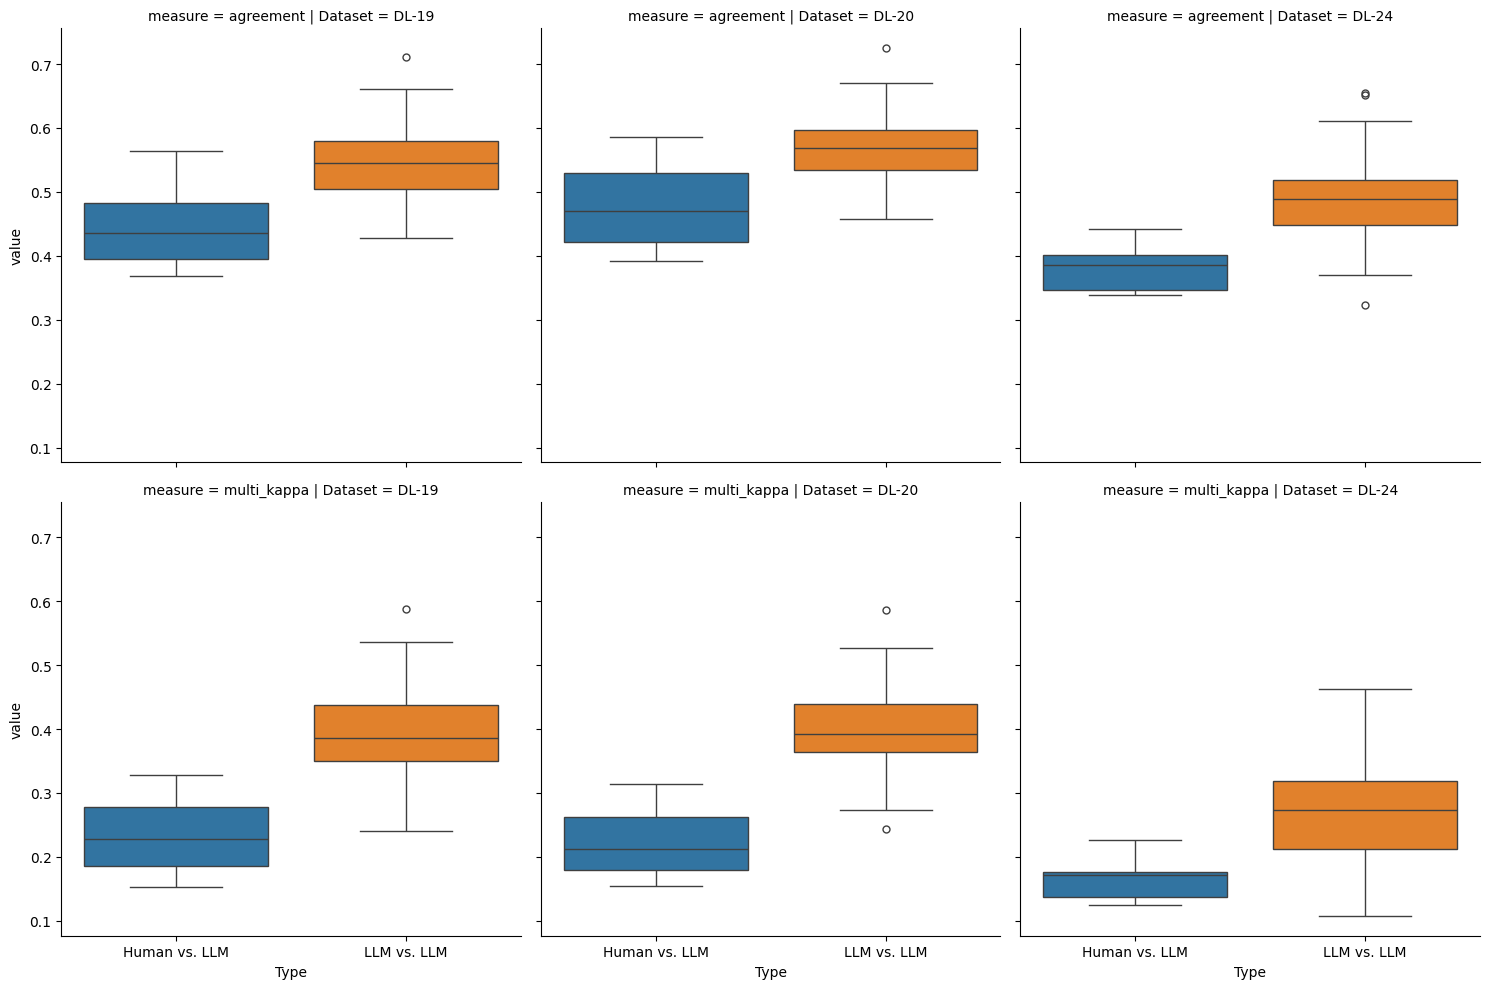

In [18]:
import seaborn as sns

sns.catplot(data=df, x='Type', y='value', hue='Type', col='Dataset', row='measure', kind='box').savefig(f'agreement-overview.pdf', bbox_inches='tight')